## Model Training and Comparison
In this section, 7 machine learning models will be trained and evaluated on a validation set. These models are: *Linear Regression*, *LASSO Regression*, *Random Forest*, *XGBoost*, *Multi-Layer Perceptron*, *Support Vector Machine*, *Voting Regressor*.


In [ ]:
## Section 1: Model Training and Comparison ##

import warnings
warnings.filterwarnings("ignore", category=UserWarning)   # Suppress unnecessary user warnings for cleaner output

from google.colab import drive
drive.mount('/content/drive')              # Mount Google Drive for file access (Colab-specific)

!pip install optuna                        # Install Optuna (hyperparameter optimization library)
import optuna                              # Import Optuna and its key components
from optuna import create_study
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

import pandas as pd
import numpy as np, random, os
import matplotlib.pyplot as plt

# Scikit-learn: Data splitting, pipeline, scaling, models, metrics, and dummy baseline
from sklearn.model_selection import KFold, GridSearchCV, train_test_split, learning_curve, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor

# For statistical comparison (paired t-tests)
from scipy.stats import ttest_rel

np.random.seed(42)
random.seed(42)
os.environ['PYTHONHASHSEED'] = '42'

def load_data(path):
    df = pd.read_csv(path)                                       # Load CSV from the provided path
    df = df.replace({'TRUE': 1, 'FALSE': 0, True: 1, False: 0})  # Convert boolean-like fields to integers
    X = df.drop(columns=['Burn Rate'])                           # Split into X and y:  X --> Features (all columns except 'Burn Rate')
    y = df['Burn Rate']                                          #                      y --> Target ('Burn Rate')
    return X, y

# Compute standard regression metrics: MAE, RMSE, R²
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return mae, rmse, r2                                         # Returns a tuple (mae, rmse, r2)

# Create model pipelines and corresponding hyperparameter grids
def make_pipelines_and_grids():
    pipes, grids = {}, {}

    pipes['Mean_Baseline'] = DummyRegressor(strategy='mean')     # Create a Dummy (mean) regressor, as a benchmark
    grids['Mean_Baseline'] = {}

    pipes['Linear'] = Pipeline([
        ('scaler', StandardScaler()),
        ('m', LinearRegression())
    ])
    grids['Linear'] = {'m__fit_intercept':[True, False]}

    pipes['Lasso'] = Pipeline([
        ('scaler', StandardScaler()),
        ('m', Lasso(max_iter=5000, random_state=42))
    ])
    grids['Lasso'] = {'m__alpha':[1e-4,1e-3,1e-2,1e-1,1,10]}

    pipes['RF'] = Pipeline([
        ('m', RandomForestRegressor(random_state=42, n_jobs=-1))
    ])
    grids['RF'] = {
        'm__n_estimators':[100,200],
        'm__max_depth':[None,10,20],
        'm__min_samples_split':[2,5,7],
        'm__min_samples_leaf':[1,2]
    }

    pipes['XGB'] = Pipeline([
        ('m', XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1))
    ])
    grids['XGB'] = {
        'm__n_estimators':[100,200],
        'm__learning_rate':[0.001,0.01,0.1],
        'm__max_depth':[3,5,7,9],
        'm__subsample':[0.6,0.8,1.0],
        'm__colsample_bytree':[0.6,0.8,1.0]
    }

    pipes['MLP'] = Pipeline([
        ('scaler', StandardScaler()),
        ('m', MLPRegressor(max_iter=1000, early_stopping=True, random_state=42))
    ])
    grids['MLP'] = {
        'm__hidden_layer_sizes':[(50,),(100,),(100,50)],
        'm__activation':['relu','tanh'],
        'm__alpha':[1e-4,1e-3,1e-2],
        'm__learning_rate':['constant','adaptive']
    }

    pipes['SVR'] = Pipeline([
        ('scaler', StandardScaler()),
        ('m', SVR())
    ])

    grids['SVR'] = {
        'm__kernel': ['rbf', 'linear'],
        'm__C': [0.01, 0.1, 1, 10],
        'm__gamma': ['scale', 'auto'],
        'm__epsilon': [0.01, 0.1, 0.5]
    }

    return pipes, grids      # Returns: pipes: dict of name --> sklearn pipeline/model
                             #          grids: dict of name --> parameter grid

# Perform nested cross-validation to avoid data leakage
def nested_cross_validation(X, y, models, param_grids, cv_outer=5, cv_inner=3):
    outer_cv = KFold(n_splits=cv_outer, shuffle=True, random_state=42)             # Outer loop --> model assessment (simulate real-world generalization)
    inner_cv = KFold(n_splits=cv_inner, shuffle=True, random_state=42)             # Inner loop --> model selection/hyperparameter tuning (GridSearchCV)
    results = []                                                                   # Store and print per-fold metrics, best hyperparameters, and pairwise t-tests
    per_model_mae = {name: [] for name in models}
    per_model_rmse = {name: [] for name in models}

    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        for name, model in models.items():
            gs = GridSearchCV(model, param_grids[name], cv=inner_cv,                # Inner CV --> tune hyperparameters for each model
                              scoring='neg_mean_absolute_error', n_jobs=-1)
            gs.fit(X_train, y_train)
            y_pred = gs.predict(X_test)
            mae, rmse, r2 = evaluate(y_test, y_pred)
            results.append({
                'Fold': fold, 'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2,
                'Best_Params': gs.best_params_
            })
            per_model_mae[name].append(mae)
            per_model_rmse[name].append(rmse)

    # MAE-based paired t-tests
    print("\n📊 Statistical Significance (Paired t-test) - MAE:")
    model_names = list(per_model_mae.keys())
    mae_results = []

    for i in range(len(model_names)):
        for j in range(i+1, len(model_names)):
            m1, m2 = model_names[i], model_names[j]
            t_stat, p_val = ttest_rel(per_model_mae[m1], per_model_mae[m2])
            signif = "✅ Significant" if p_val < 0.05 else "❌ Not significant"
            mae_results.append({
                'Model 1': m1, 'Model 2': m2,
                't-stat': round(t_stat, 4), 'p-value': round(p_val, 4),
                'Result': signif
            })

    mae_df = pd.DataFrame(mae_results)
    print(mae_df.to_string(index=False))

    # RMSE-based paired t-tests
    print("\n📊 Statistical Significance (Paired t-test) - RMSE:")
    rmse_results = []

    for i in range(len(model_names)):
        for j in range(i+1, len(model_names)):
            m1, m2 = model_names[i], model_names[j]
            t_stat, p_val = ttest_rel(per_model_rmse[m1], per_model_rmse[m2])
            signif = "✅ Significant" if p_val < 0.05 else "❌ Not significant"
            rmse_results.append({
                'Model 1': m1, 'Model 2': m2,
                't-stat': round(t_stat, 4), 'p-value': round(p_val, 4),
                'Result': signif
            })

    rmse_df = pd.DataFrame(rmse_results)
    print(rmse_df.to_string(index=False))

    return pd.DataFrame(results), mae_df, rmse_df    # Return metrics for each fold/model & paired t-test results for MAE, RMSE

if __name__ == '__main__':
    # 1. Load the dataset & Split features and target variable
    path = '/content/drive/My Drive/Burnout/new_train.csv'
    X, y = load_data(path)

    # 2. Perform model comparison with nested CV
    pipes, grids = make_pipelines_and_grids()
    print("Starting nested cross-validation for model comparison...")
    summary_df, mae_significance_df, rmse_significance_df = nested_cross_validation(
        X, y, pipes, grids, cv_outer=5, cv_inner=3
    )

    # Print mean metrics per model
    print("\nMean validation results (across outer folds):")
    mean_results = summary_df.groupby('Model')[['MAE', 'RMSE', 'R2']] \
                             .mean() \
                             .sort_values('RMSE') \
                             .reset_index()
    mean_results = mean_results.round(4)
    print(mean_results.to_string(index=False))

    # Print best hyperparameters for each model
    print("\nBest hyperparameters per model:")
    for name in pipes.keys():
        params = summary_df[summary_df['Model'] == name]['Best_Params'].iloc[0]
        print(f"  {name}: {params}")

    # 3. Find best model both for MAE and RMSE
    best_mae_model  = mean_results.loc[mean_results['MAE'].idxmin()]['Model']
    best_rmse_model = mean_results.loc[mean_results['RMSE'].idxmin()]['Model']
    print(f"\nBest by mean MAE:  {best_mae_model}")
    print(f"Best by mean RMSE: {best_rmse_model}")

    # 4. Save splits for later (Optuna training)
    X_tv, X_test, y_tv, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_tv, y_tv, test_size=0.25, random_state=42)
    np.savez('splits_for_optuna.npz',
             X_train=X_train.values, X_val=X_val.values, X_test=X_test.values,
             y_train=y_train.values, y_val=y_val.values, y_test=y_test.values,
             columns=np.array(X.columns))

    # Add a Voting Regressor using best parameters for all models (Mean_Baseline not included)
    print("\n========== VotingRegressor Section ==========")
    best_param_dict = {}
    for name in pipes.keys():
        if name == 'Mean_Baseline':
            continue
        best_param_dict[name] = summary_df[summary_df['Model'] == name]['Best_Params'].iloc[0]

    best_models = []                  # Build new model objects using best found parameters per model
    for name in pipes.keys():
        if name == 'Mean_Baseline':
            continue

        # Re-create models with their best paramaterers (strip 'm__')
        if name == 'Linear':
            model = Pipeline([
                ('scaler', StandardScaler()),
                ('m', LinearRegression(**{k.replace('m__',''):v for k,v in best_param_dict[name].items()}))
            ])
        elif name == 'Lasso':
            model = Pipeline([
                ('scaler', StandardScaler()),
                ('m', Lasso(max_iter=5000, random_state=42, **{k.replace('m__',''):v for k,v in best_param_dict[name].items()}))
            ])
        elif name == 'RF':
            model = Pipeline([
                ('m', RandomForestRegressor(random_state=42, n_jobs=-1, **{k.replace('m__',''):v for k,v in best_param_dict[name].items()}))
            ])
        elif name == 'XGB':
            model = Pipeline([
                ('m', XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1, **{k.replace('m__',''):v for k,v in best_param_dict[name].items()}))
            ])
        elif name == 'MLP':
            model = Pipeline([
                ('scaler', StandardScaler()),
                ('m', MLPRegressor(max_iter=1000, early_stopping=True, random_state=42, **{k.replace('m__',''):v for k,v in best_param_dict[name].items()}))
            ])
        elif name == 'SVR':
            model = Pipeline([
                ('scaler', StandardScaler()),
                ('m', SVR(**{k.replace('m__',''):v for k,v in best_param_dict[name].items()}))
            ])
        else:
            continue
        best_models.append((name, model))

    # Fit VotingRegressor on ALL data and evaluate (for reference, not cross-validated)
    voting_reg = VotingRegressor(estimators=best_models)
    voting_reg.fit(X, y)
    voting_pred = voting_reg.predict(X)
    mae_voting, rmse_voting, r2_voting = evaluate(y, voting_pred)
    print("\n[ADDED] VotingRegressor on ALL DATA (for reference):")
    print(f" Voting MAE: {mae_voting:.4f}, RMSE: {rmse_voting:.4f}, R2: {r2_voting:.4f}")

    # Nested cross-validated VotingRegressor (for fair comparison to single models)
    outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)
    voting_pred_cv = cross_val_predict(voting_reg, X, y, cv=outer_cv)
    mae_voting_cv, rmse_voting_cv, r2_voting_cv = evaluate(y, voting_pred_cv)
    print("\n[ADDED] VotingRegressor (cross-validated):")
    print(f" Voting MAE (CV): {mae_voting_cv:.4f}, RMSE (CV): {rmse_voting_cv:.4f}, R2 (CV): {r2_voting_cv:.4f}")

    # Add VotingRegressor's per-fold metrics to summary_df for summary table
    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y), 1):
        X_test = X.iloc[test_idx]
        y_test = y.iloc[test_idx]
        y_pred = voting_reg.fit(X.iloc[train_idx], y.iloc[train_idx]).predict(X_test)
        mae, rmse, r2 = evaluate(y_test, y_pred)
        # Add to summary_df
        summary_df = pd.concat([
            summary_df,
            pd.DataFrame([{
                'Fold': fold,
                'Model': 'VotingRegressor',
                'MAE': mae,
                'RMSE': rmse,
                'R2': r2,
                'Best_Params': str({name: best_param_dict[name] for name in best_param_dict})
            }])
        ], ignore_index=True)
    print("========== End VotingRegressor Section ==========\n")

    print("\nStatistical Significance: VotingRegressor vs Each Model")   # Further perform Statistical Significance: VotingRegressor vs Other Models

    # Collect MAE/RMSE per fold for VotingRegressor and Other Models
    voting_mae = summary_df[summary_df['Model'] == 'VotingRegressor'].sort_values('Fold')['MAE'].values
    voting_rmse = summary_df[summary_df['Model'] == 'VotingRegressor'].sort_values('Fold')['RMSE'].values

    other_models = [m for m in summary_df['Model'].unique() if m != 'VotingRegressor']

    # MAE significance test
    print("\n[MAE] VotingRegressor vs Other Models:")
    for m in other_models:
        other_mae = summary_df[summary_df['Model'] == m].sort_values('Fold')['MAE'].values
        t_stat, p_val = ttest_rel(voting_mae, other_mae)
        signif = "✅ Significant" if p_val < 0.05 else "❌ Not significant"
        print(f"  VotingRegressor vs {m:>16s} : t={t_stat:.4f}, p={p_val:.4f}, {signif}")

    # RMSE significance test
    print("\n[RMSE] VotingRegressor vs Other Models:")
    for m in other_models:
        other_rmse = summary_df[summary_df['Model'] == m].sort_values('Fold')['RMSE'].values
        t_stat, p_val = ttest_rel(voting_rmse, other_rmse)
        signif = "✅ Significant" if p_val < 0.05 else "❌ Not significant"
        print(f"  VotingRegressor vs {m:>16s} : t={t_stat:.4f}, p={p_val:.4f}, {signif}")

    # Print overall mean metrics for all models, including VotingRegressore
    print("\nMean validation results (including VotingRegressor):")
    mean_results = summary_df.groupby('Model')[['MAE', 'RMSE', 'R2']] \
                             .mean() \
                             .sort_values('RMSE') \
                             .reset_index()
    mean_results = mean_results.round(4)
    print(mean_results.to_string(index=False))

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.0/247.0 kB 28.0 MB/s eta 0:00:00
Starting nested cross-validation for model comparison...


/tmp/ipython-input-3852181794.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({'TRUE': 1, 'FALSE': 0, True: 1, False: 0})  # Convert boolean-like fields to integers



📊 Statistical Significance (Paired t-test) - MAE:
      Model 1 Model 2   t-stat  p-value            Result
Mean_Baseline  Linear 115.6553   0.0000     ✅ Significant
Mean_Baseline   Lasso 115.8091   0.0000     ✅ Significant
Mean_Baseline      RF 118.6015   0.0000     ✅ Significant
Mean_Baseline     XGB 113.8473   0.0000     ✅ Significant
Mean_Baseline     MLP 119.0040   0.0000     ✅ Significant
Mean_Baseline     SVR 114.4570   0.0000     ✅ Significant
       Linear   Lasso   0.6903   0.5280 ❌ Not significant
       Linear      RF  27.3733   0.0000     ✅ Significant
       Linear     XGB  26.5433   0.0000     ✅ Significant
       Linear     MLP  10.7148   0.0004     ✅ Significant
       Linear     SVR  35.9871   0.0000     ✅ Significant
        Lasso      RF  26.6512   0.0000     ✅ Significant
        Lasso     XGB  26.1273   0.0000     ✅ Significant
        Lasso     MLP  10.4953   0.0005     ✅ Significant
        Lasso     SVR  35.4132   0.0000     ✅ Significant
           RF     XGB

*XGBoost* performed slightly better than all the other models. However, it presented no statistical difference to the *Random Forest*, but only in terms of *Mean Absolute Error*. For this reason, the next step is to further tune XGBoost and try to find its best optimal hyperparameters. To do this, the *Optuna* library will be used.

## XGBoost - Hyperparameter Optimization with Optuna

[I 2025-08-12 17:45:20,693] A new study created in memory with name: no-name-69f8c2cc-f35b-4feb-80e4-85d88af72a0e



Trial results:


[I 2025-08-12 17:45:36,728] Trial 0 finished with value: 0.050486533170867376 and parameters: {'n_estimators': 1186, 'learning_rate': 0.6351221010640696, 'max_depth': 12, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'reg_alpha': 6.025215736203858e-05, 'reg_lambda': 1.951722464144947e-05}. Best is trial 0 with value: 0.050486533170867376.


Trial 0 finished with value: 0.050487 and parameters: {'n_estimators': 1186, 'learning_rate': 0.6351221010640696, 'max_depth': 12, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'reg_alpha': 6.025215736203858e-05, 'reg_lambda': 1.951722464144947e-05}
Best so far: Trial 0 value: 0.050487, params: {'n_estimators': 1186, 'learning_rate': 0.6351221010640696, 'max_depth': 12, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'reg_alpha': 6.025215736203858e-05, 'reg_lambda': 1.951722464144947e-05}



[I 2025-08-12 17:46:14,889] Trial 1 finished with value: 0.045304223127088566 and parameters: {'n_estimators': 2612, 'learning_rate': 0.02537815508265665, 'max_depth': 12, 'subsample': 0.5102922471479012, 'colsample_bytree': 0.9849549260809971, 'reg_alpha': 0.1452824663751603, 'reg_lambda': 0.00011526449540315612}. Best is trial 1 with value: 0.045304223127088566.


...

Trial 97 pruned.
Best so far: Trial 52 value: 0.042963, params: {'n_estimators': 788, 'learning_rate': 0.006898546839320549, 'max_depth': 6, 'subsample': 0.6919002009978714, 'colsample_bytree': 0.7301631111795839, 'reg_alpha': 1.1127968534340953e-05, 'reg_lambda': 0.0002193631522224463}



[I 2025-08-12 17:58:18,050] Trial 98 finished with value: 0.043888813753598224 and parameters: {'n_estimators': 483, 'learning_rate': 0.027378742714255336, 'max_depth': 10, 'subsample': 0.9480383803864251, 'colsample_bytree': 0.6370072480247144, 'reg_alpha': 7.562117192816307e-05, 'reg_lambda': 3.562613438772399e-05}. Best is trial 52 with value: 0.04296274968367897.


Trial 98 finished with value: 0.043889 and parameters: {'n_estimators': 483, 'learning_rate': 0.027378742714255336, 'max_depth': 10, 'subsample': 0.9480383803864251, 'colsample_bytree': 0.6370072480247144, 'reg_alpha': 7.562117192816307e-05, 'reg_lambda': 3.562613438772399e-05}
Best so far: Trial 52 value: 0.042963, params: {'n_estimators': 788, 'learning_rate': 0.006898546839320549, 'max_depth': 6, 'subsample': 0.6919002009978714, 'colsample_bytree': 0.7301631111795839, 'reg_alpha': 1.1127968534340953e-05, 'reg_lambda': 0.0002193631522224463}



[I 2025-08-12 17:58:18,970] Trial 99 pruned. 


Trial 99 pruned.
Best so far: Trial 52 value: 0.042963, params: {'n_estimators': 788, 'learning_rate': 0.006898546839320549, 'max_depth': 6, 'subsample': 0.6919002009978714, 'colsample_bytree': 0.7301631111795839, 'reg_alpha': 1.1127968534340953e-05, 'reg_lambda': 0.0002193631522224463}


Study statistics:
Number of finished trials:  100
Number of pruned trials:  31
Number of complete trials:  69

Best trial:
  Mean CV MAE: 0.042963
  Mean CV RMSE: 0.053135
  Params: 
    n_estimators: 788
    learning_rate: 0.006898546839320549
    max_depth: 6
    subsample: 0.6919002009978714
    colsample_bytree: 0.7301631111795839
    reg_alpha: 1.1127968534340953e-05
    reg_lambda: 0.0002193631522224463

Test set performance → MAE: 0.0429, RMSE: 0.0527, R²: 0.9277

Plotting learning curve…


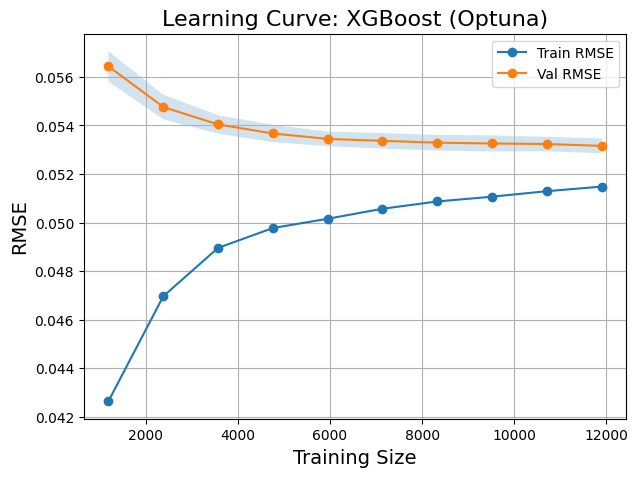


Plotting residuals…


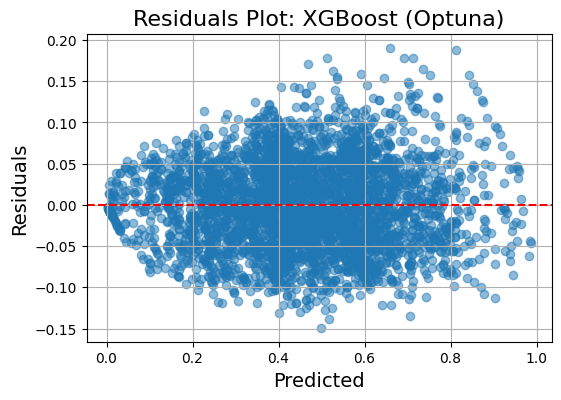


Plotting feature importances…


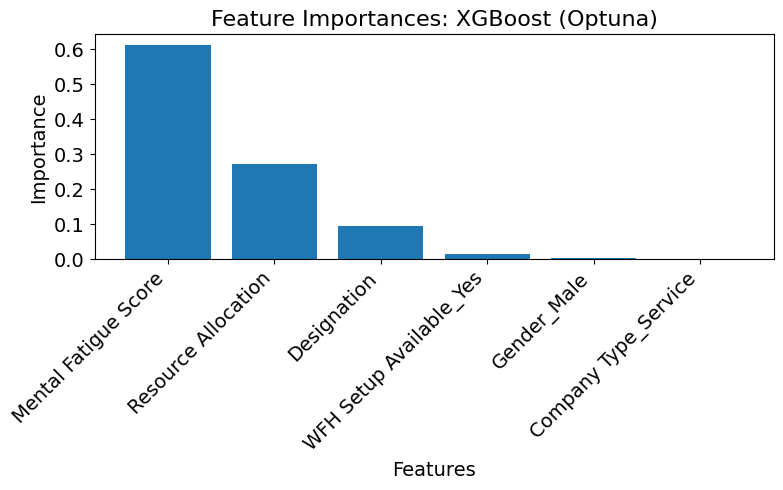

In [ ]:
## Section 2: Optuna Optimization for XGBoost ##

warnings.filterwarnings("ignore", category=FutureWarning, module='optuna')    # To hide future warnings from Optuna for clean output

#  Load pre-saved train/validation/test splits (and column names) from a ".npz" file
def load_splits(npz_path: str):
    data = np.load(npz_path, allow_pickle=True)
    cols = data['columns'].tolist()
    X_train = pd.DataFrame(data['X_train'], columns=cols)
    X_val   = pd.DataFrame(data['X_val'],   columns=cols)
    X_test  = pd.DataFrame(data['X_test'],  columns=cols)
    y_train = pd.Series(data['y_train'], name='Burn Rate')
    y_val   = pd.Series(data['y_val'],   name='Burn Rate')
    y_test  = pd.Series(data['y_test'],  name='Burn Rate')
    return X_train, X_val, X_test, y_train, y_val, y_test

# Convert columns of object dtype to numeric, if possible (for ML model compatibility)
def convert_objects_to_numeric(df: pd.DataFrame) -> pd.DataFrame:
    for col in df.columns:
        if df[col].dtype == 'object':
            df[col] = pd.to_numeric(df[col])
    return df

# Compute and return the evaluation metrics: MAE, RMSE, R2
def evaluate(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return mae, rmse, r2

# Plot learning curve of RMSE versus training set size
def plot_learning_curve(estimator, X, y, title):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y,
        cv=5,                                                  # Use 5-fold cross-validation
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        shuffle=True,
        random_state=42
    )
    train_rmse = np.sqrt(-train_scores)
    val_rmse   = np.sqrt(-val_scores)

    plt.figure(figsize=(7,5))
    plt.plot(train_sizes, train_rmse.mean(axis=1), 'o-', label='Train RMSE')
    plt.plot(train_sizes, val_rmse.mean(axis=1),   'o-', label='Val RMSE')
    plt.fill_between(
        train_sizes,
        val_rmse.mean(axis=1) - val_rmse.std(axis=1),
        val_rmse.mean(axis=1) + val_rmse.std(axis=1),
        alpha=0.2
    )
    plt.xlabel("Training Size", fontsize=14)
    plt.ylabel("RMSE", fontsize=14)
    plt.title(f"Learning Curve: {title}", fontsize=16)
    plt.legend()
    plt.grid(True)
    plt.show()

    return train_sizes, train_rmse, val_rmse

# Plot residuals (errors) VS predicted values
def plot_residuals(y_true, y_pred, title):
    residuals = y_true - y_pred
    plt.figure(figsize=(6,4))
    plt.scatter(y_pred, residuals, alpha=0.5)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel("Predicted", fontsize=14)
    plt.ylabel("Residuals", fontsize=14)
    plt.title(f"Residuals Plot: {title}", fontsize=16)
    plt.grid(True)
    plt.show()

    return y_pred, residuals

# Plot and save a feature importance bar chart
def plot_feature_importance(model, feature_names, title):
    if hasattr(model, 'feature_importances_'):       # To plot only for models that provide feature importance (XGBoost provides it)
        imp = model.feature_importances_
    else:
        print("No feature_importances_ available for this model.")
        return
    idxs = np.argsort(imp)[::-1]                     # Indices for sorting in descending order
    plt.figure(figsize=(8,5))
    plt.bar(range(len(imp)), imp[idxs])
    plt.xticks(range(len(imp)), np.array(feature_names)[idxs], rotation=45, ha='right', fontsize=14)
    plt.yticks(fontsize=14)
    plt.xlabel("Features", fontsize=14)
    plt.ylabel("Importance", fontsize=14)
    plt.title(f"Feature Importances: {title}", fontsize=16)
    plt.tight_layout()
    plt.show()

    # To save this plot as image
    plt.figure(figsize=(8,5))
    plt.bar(range(len(imp)), imp[idxs])
    plt.xticks(range(len(imp)), np.array(feature_names)[idxs], rotation=45, ha='right', fontsize=14)
    plt.yticks(fontsize=14)
    plt.xlabel("Features", fontsize=14)
    plt.ylabel("Importance", fontsize=14)
    plt.title(f"Feature Importances: {title}", fontsize=16)
    plt.tight_layout()
    plt.savefig("feature_importances.png", dpi=300)
    plt.close()


# Use Optuna to optimize XGBoost hyperparameters (objective is to minimize for Mean Cross-validated MAE)
def tune_xgb_with_optuna(X_full, y_full, n_trials=100, timeout=3600):    # n_trials --> number of hyperparameter trials
                                                                         # timeout ---> maximum time in seconds (if still running, stop after 1 hour)
    trial_results = []
    best_trial = [None]

    # Suggest hyperparameters' range for Optuna to search
    def objective(trial):
        params = {
            "n_estimators":     trial.suggest_int("n_estimators", 100, 3000),
            "learning_rate":    trial.suggest_float("learning_rate", 1e-4, 1, log=True),
            "max_depth":        trial.suggest_int("max_depth", 2, 16),
            "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "reg_alpha":        trial.suggest_float("reg_alpha", 1e-5, 1.0, log=True),
            "reg_lambda":       trial.suggest_float("reg_lambda", 1e-5, 1.0, log=True),
            "random_state":     42,
            "n_jobs":           -1,
            "objective":        "reg:squarederror",
            "eval_metric":      "mae",
        }
        cv = KFold(n_splits=5, shuffle=True, random_state=42)            # 5-fold CV loop for MAE calculation
        maes = []
        for fold, (t_idx, v_idx) in enumerate(cv.split(X_full, y_full)):
            X_tr, X_val = X_full.iloc[t_idx], X_full.iloc[v_idx]
            y_tr, y_val = y_full.iloc[t_idx], y_full.iloc[v_idx]

            model = XGBRegressor(**params)
            model.fit(
                X_tr, y_tr,
                eval_set=[(X_val, y_val)],
                verbose=False,
            )
            pred = model.predict(X_val)
            mae = mean_absolute_error(y_val, pred)
            maes.append(mae)
            trial.report(mae, step=fold)           # Report intermediate result for pruning
            if trial.should_prune():
                raise optuna.TrialPruned()
        return float(np.mean(maes))                # Minimize mean CV MAE

    # Callback to log trial info after each trial, and track best so far (helpful for reporting purposes)
    def print_after_trial(study, trial):
        trial_results.append(trial)
        if trial.state == optuna.trial.TrialState.COMPLETE:
            print(f"Trial {trial.number} finished with value: {trial.value:.6f} and parameters: {trial.params}")
        elif trial.state == optuna.trial.TrialState.PRUNED:
            print(f"Trial {trial.number} pruned.")
        current_best = study.best_trial
        if best_trial[0] is None or current_best.value < best_trial[0].value:
            best_trial[0] = current_best
        print(f"Best so far: Trial {current_best.number} value: {current_best.value:.6f}, params: {current_best.params}\n")

    # Create Optuna study with TPE sampler (Bayesian) and MedianPruner for early stopping
    study = create_study(
        direction="minimize",
        sampler=TPESampler(seed=42),
        pruner=MedianPruner(n_warmup_steps=1),
    )
    study.optimize(objective, n_trials=n_trials, timeout=timeout, callbacks=[print_after_trial])
    return study.best_trial.params, study     # Return best hyperparameters dictionary and the full Optuna study object

# Given XGB parameters, return mean MAE and RMSE using 5-fold cross-validation
def crossval_mae_rmse(params, X, y):
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    maes, rmses = [], []
    for train_idx, val_idx in cv.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        model = XGBRegressor(**params,
                             objective='reg:squarederror',
                             random_state=42,
                             n_jobs=-1)
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        pred = model.predict(X_val)
        mae = mean_absolute_error(y_val, pred)
        rmse = np.sqrt(mean_squared_error(y_val, pred))
        maes.append(mae)
        rmses.append(rmse)
    return np.mean(maes), np.mean(rmses)

if __name__ == '__main__':
    # 1. Load train/val/test splits (from file produced in Section 1)
    X_train, X_val, X_test, y_train, y_val, y_test = load_splits('splits_for_optuna.npz')

    # 2. Convert object dtype columns to numeric, for each split
    for df in (X_train, X_val, X_test):
        convert_objects_to_numeric(df)

    # 3. Combine train + val for Optuna tuning (use Optuna's best hyperparameters but now in all data except the test split, and evaluate there)
    X_full = pd.concat([X_train, X_val], ignore_index=True)
    y_full = pd.concat([y_train, y_val], ignore_index=True)

    print("\nTrial results:")
    best_params, study = tune_xgb_with_optuna(X_full, y_full, n_trials=100, timeout=3600)

    print("\nStudy statistics:")
    print("Number of finished trials: ", len(study.trials))
    print("Number of pruned trials: ", len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED]))
    print("Number of complete trials: ", len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]))

    # 4. Compute CV metrics for the best Optuna trial's parameters
    best_trial = study.best_trial
    mae_cv, rmse_cv = crossval_mae_rmse(best_trial.params, X_full, y_full)
    print("\nBest trial:")
    print("  Mean CV MAE: {:.6f}".format(mae_cv))
    print("  Mean CV RMSE: {:.6f}".format(rmse_cv))
    print("  Params: ")
    for k, v in best_trial.params.items():
        print(f"    {k}: {v}")

    # 5. Final fit on train + val, then test on holdout test set
    final = XGBRegressor(**best_params,
                         objective='reg:squarederror',
                         random_state=42,
                         n_jobs=-1)
    final.fit(X_full, y_full)

    y_test_pred = final.predict(X_test)
    mae_t, rmse_t, r2_t = evaluate(y_test, y_test_pred)
    print(f"\nTest set performance → MAE: {mae_t:.4f}, RMSE: {rmse_t:.4f}, R²: {r2_t:.4f}")

    # Extra section to plot and save the plots (for the report)

    # Learning curve
    print("\nPlotting learning curve…")
    train_sizes, train_rmse, val_rmse = plot_learning_curve(final, X_full, y_full, "XGBoost (Optuna)")

    # Residuals
    print("\nPlotting residuals…")
    y_pred_data, residuals_data = plot_residuals(y_test, y_test_pred, "XGBoost (Optuna)")

    # Combined plot: learning curve and residuals side-by-side, saved to file
    fig, axes = plt.subplots(1, 2, figsize=(14,5))
    axes[0].plot(train_sizes, train_rmse.mean(axis=1), 'o-', label='Train RMSE')
    axes[0].plot(train_sizes, val_rmse.mean(axis=1), 'o-', label='Val RMSE')
    axes[0].fill_between(train_sizes,
                         val_rmse.mean(axis=1) - val_rmse.std(axis=1),
                         val_rmse.mean(axis=1) + val_rmse.std(axis=1),
                         alpha=0.2)
    axes[0].set_xlabel("Training Size", fontsize=16)
    axes[0].set_ylabel("RMSE", fontsize=16)
    axes[0].set_title("Learning Curve: XGBoost (Optuna)", fontsize=18)
    axes[0].tick_params(axis='both', which='major', labelsize=14)
    axes[0].legend(fontsize=14)
    axes[0].grid(True)

    # Residuals subplot
    axes[1].scatter(y_pred_data, residuals_data, alpha=0.5)
    axes[1].axhline(0, color='red', linestyle='--')
    axes[1].set_xlabel("Predicted", fontsize=16)
    axes[1].set_ylabel("Residuals", fontsize=16)
    axes[1].set_title("Residuals Plot: XGBoost (Optuna)", fontsize=18)
    axes[1].tick_params(axis='both', which='major', labelsize=14)
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig("learning_residuals_combined.png", dpi=300)
    plt.close()

    # Feature importances
    print("\nPlotting feature importances…")
    plot_feature_importance(final, X_full.columns, "XGBoost (Optuna)")

Comments:
*   In the learning curve, the training *RMSE* increases as training size grows, while validation RMSE decreases at the same time. This is expected to happen since more data induces more complexity in the model. Both the training and validation *RMSE* plateau around the value of 0.052, suggesting that *XGBoost* generalizes fairly well. The small gap indicates some potential but not severe
overfitting, however, adding more data may not bring big improvements in the current setting.
*   The residuals plot shows an almost symmetric distribution of errors around zero, meaning that the model captures most of the non-linear relationships. Nevertheless, the spread of the residuals is not constant across the predicted range, as the variance of the errors increases at higher values of
burnout. This indicates that the algorithm might struggle to generalize accurately when employees exhibit substantial burn rates.
*   From the feature importance figure, it is clear that *Mental Fatigue Score* is by far the most important feature with almost 60% importance. This is followed by *Resource Allocation* and *Designation*, which exhibit levels round 25% and 10%, respectively. The rest of the features, like *Work-From-Home
Setup Availability*, *Gender*, and *Company Type* contribute minimally to predicting burnout rates.





## Evalute and compare XGBoost before and after Optuna, and Voting Regressor with new XGBoost parameters

In [ ]:
## Section 3: XGBoost Optuna + New Family VotingRegressor + Statistical Comparison ##

# Fit new Optuna-tuned XGBoost on train+val, predict on X_test
final_xgb_optuna = XGBRegressor(**best_params,
                                objective='reg:squarederror',
                                random_state=42,
                                n_jobs=-1)
final_xgb_optuna.fit(X_full, y_full)
y_pred_xgb_optuna = final_xgb_optuna.predict(X_test)
mae_xgb_optuna, rmse_xgb_optuna, r2_xgb_optuna = evaluate(y_test, y_pred_xgb_optuna)
print(f"\n[Optuna XGBoost] Test: MAE={mae_xgb_optuna:.4f}, RMSE={rmse_xgb_optuna:.4f}, R2={r2_xgb_optuna:.4f}")

# Fit previous best XGBoost (from Section 1) on train+val, predict on X_test
xgb_old_params = {k.replace('m__',''):v for k,v in best_param_dict['XGB'].items()}
final_xgb_old = XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1, **xgb_old_params)
final_xgb_old.fit(X_full, y_full)
y_pred_xgb_old = final_xgb_old.predict(X_test)
mae_xgb_old, rmse_xgb_old, r2_xgb_old = evaluate(y_test, y_pred_xgb_old)
print(f"[OLD XGBoost]    Test: MAE={mae_xgb_old:.4f}, RMSE={rmse_xgb_old:.4f}, R2={r2_xgb_old:.4f}")

# Fit old VotingRegressor on train+val, predict on X_test
voting_reg_old = VotingRegressor(estimators=best_models)
voting_reg_old.fit(X_full, y_full)
y_pred_voting_old = voting_reg_old.predict(X_test)
mae_voting_old, rmse_voting_old, r2_voting_old = evaluate(y_test, y_pred_voting_old)
print(f"[OLD VotingReg]  Test: MAE={mae_voting_old:.4f}, RMSE={rmse_voting_old:.4f}, R2={r2_voting_old:.4f}")

# Fit new VotingRegressor (with Optuna-tuned XGB) on train+val, predict on X_test
best_models_new = []
for name, model in best_models:
    if name == 'XGB':
        # Replace old XGB with new Optuna-tuned XGB for fair ensemble comparison
        new_xgb_pipe = Pipeline([
            ('m', XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1, **best_params))
        ])
        best_models_new.append(('XGB', new_xgb_pipe))
    else:
        best_models_new.append((name, model))
voting_reg_new = VotingRegressor(estimators=best_models_new)
voting_reg_new.fit(X_full, y_full)
y_pred_voting_new = voting_reg_new.predict(X_test)
mae_voting_new, rmse_voting_new, r2_voting_new = evaluate(y_test, y_pred_voting_new)
print(f"[NEW VotingReg]  Test: MAE={mae_voting_new:.4f}, RMSE={rmse_voting_new:.4f}, R2={r2_voting_new:.4f}")

# Perform Statistical Significance tests (paired t-test) for all pairs
print("\nStatistical significance (paired t-test, predictions on test set):")
from itertools import combinations
predictions_dict = {
    'VotingReg-OLD': y_pred_voting_old,
    'VotingReg-NEW': y_pred_voting_new,
    'XGB-OLD':       y_pred_xgb_old,
    'XGB-Optuna':    y_pred_xgb_optuna,
}
for m1, m2 in combinations(predictions_dict.keys(), 2):
    t_stat, p_val = ttest_rel(predictions_dict[m1], predictions_dict[m2])
    signif = "✅ Significant" if p_val < 0.05 else "❌ Not significant"
    print(f"  {m1:13s} vs {m2:13s} : t={t_stat:.4f}, p={p_val:.4f} {signif}")

# Print Summary table
summary_table = pd.DataFrame([
    {"Model": "VotingReg-OLD", "MAE": mae_voting_old, "RMSE": rmse_voting_old, "R2": r2_voting_old},
    {"Model": "VotingReg-NEW", "MAE": mae_voting_new, "RMSE": rmse_voting_new, "R2": r2_voting_new},
    {"Model": "XGB-OLD",       "MAE": mae_xgb_old,    "RMSE": rmse_xgb_old,    "R2": r2_xgb_old},
    {"Model": "XGB-Optuna",    "MAE": mae_xgb_optuna, "RMSE": rmse_xgb_optuna, "R2": r2_xgb_optuna},
])
print("\n===== SUMMARY TABLE (Test set) =====")
print(summary_table.round(4).to_string(index=False))


[Optuna XGBoost] Test: MAE=0.0429, RMSE=0.0527, R2=0.9277
[OLD XGBoost]    Test: MAE=0.0429, RMSE=0.0525, R2=0.9282
[OLD VotingReg]  Test: MAE=0.0432, RMSE=0.0528, R2=0.9273
[NEW VotingReg]  Test: MAE=0.0432, RMSE=0.0529, R2=0.9272

Statistical significance (paired t-test, predictions on test set):
  VotingReg-OLD vs VotingReg-NEW : t=1.7994, p=0.0720 ❌ Not significant
  VotingReg-OLD vs XGB-OLD       : t=2.9990, p=0.0027 ✅ Significant
  VotingReg-OLD vs XGB-Optuna    : t=5.0092, p=0.0000 ✅ Significant
  VotingReg-NEW vs XGB-OLD       : t=2.6072, p=0.0092 ✅ Significant
  VotingReg-NEW vs XGB-Optuna    : t=4.8409, p=0.0000 ✅ Significant
  XGB-OLD       vs XGB-Optuna    : t=1.7994, p=0.0720 ❌ Not significant

===== SUMMARY TABLE (Test set) =====
        Model    MAE   RMSE     R2
VotingReg-OLD 0.0432 0.0528 0.9273
VotingReg-NEW 0.0432 0.0529 0.9272
      XGB-OLD 0.0429 0.0525 0.9282
   XGB-Optuna 0.0429 0.0527 0.9277


Boosting still outperforms the Voting model when evaluated in out-of-sample data, while the prime
version of XGBoost barely exceeds its own performance, even after being tuned with Optuna.
Even though all regressors exhibit very similar evaluation metrics, there is no statistical difference
between the two XGBoost models, while both suggest individual variation from the Voting ones.